In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import pathlib
data = pathlib.Path('/content/drive/My Drive/brain_tumor_two')
!pip install mplcyberpunk




In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mplcyberpunk
plt.style.use("cyberpunk")
import cv2
import tensorflow as tf
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D, BatchNormalization, Activation, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from tensorflow.keras.regularizers import l2
from warnings import filterwarnings



In [ ]:
# Data Preparation
X_train = []
y_train = []
labels = ['glioma_tumor', 'no_tumor', 'meningioma_tumor', 'pituitary_tumor']
image_size =300

for i in labels:
    folderPath = os.path.join('/content/drive/My Drive/brain_tumor_two/Training_two', i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath, j))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        y_train.append(i)

for i in labels:
    folderPath = os.path.join('/content/drive/My Drive/brain_tumor_two/Testing_two', i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath, j))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        y_train.append(i)

X_train = np.array(X_train)
y_train = np.array(y_train)



100%|██████████| 300/300 [00:07<00:00, 42.46it/s] 


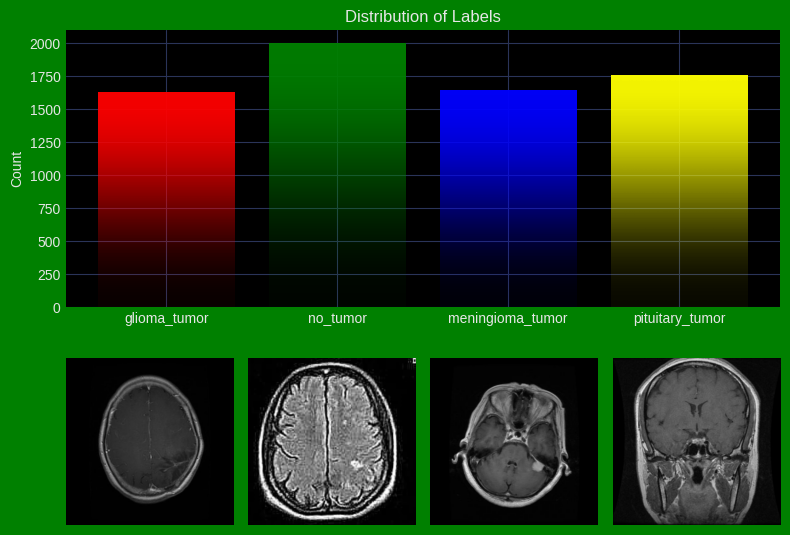

In [ ]:
# Data visualization
label_counts = {label: np.sum(y_train == label) for label in labels}

plt.figure(figsize=(8, 6), facecolor='Green')
colors = ['red', 'green', 'blue', 'yellow']

plt.subplot(2, 1, 1, facecolor='black')
bars = plt.bar(label_counts.keys(), label_counts.values(), color=colors)
mplcyberpunk.add_bar_gradient(bars=bars)
plt.ylabel('Count')
plt.title('Distribution of Labels')

k = 0
for i in labels:
    j = 0
    while True:
        if y_train[j] == i:
            plt.subplot(2, 4, k + 5)
            plt.imshow(X_train[j])
            plt.axis('off')
            k += 1
            break
        j += 1

plt.tight_layout()
plt.show()



In [ ]:
X_train, y_train = shuffle(X_train, y_train, random_state=101)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=101)
#Normalization
X_train = X_train / 255
X_test = X_test / 255


In [ ]:
y_train_new = [labels.index(i) for i in y_train]
y_train = tf.keras.utils.to_categorical(y_train_new)

y_test_new = [labels.index(i) for i in y_test]
y_test = tf.keras.utils.to_categorical(y_test_new)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
# Model Training
l2_values = [0.001]
results = {}

for l2_value in l2_values:
    print(f'Training with L2 regularization: {l2_value}')

    model = Sequential()
    model.add(Conv2D(32, (9, 9), padding='same', kernel_regularizer=l2(l2_value), input_shape=(image_size, image_size, 3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (9, 9), padding='same', kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (9, 9), padding='same', kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(256, (9, 9), padding='same', kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(512, (9, 9), padding='same', kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(1024, (9, 9), padding='same', kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(2048, (9, 9), padding='same', kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(GlobalAveragePooling2D())
    model.add(Flatten())
    model.add(Dense(2048, kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1024, kernel_regularizer=l2(l2_value)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    model.add(Dense(4, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Display model summary
    model.summary()

    # Define callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    tensorboard = TensorBoard(log_dir='logs')
    checkpoint = ModelCheckpoint("model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-7, verbose=1)

    # Train the model
    class_weights = {0: 2.0, 1: 2.0, 2: 2.0, 3: 2.0}
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_test, y_test),
        epochs=50,
        verbose=1,
        class_weight=class_weights,
        callbacks=[early_stopping, tensorboard, checkpoint, reduce_lr]
    )

    results[l2_value] = history.history

best_l2 = max(results, key=results.get)
print(f"Best L2 regularization value: {best_l2}")
print(f"Validation accuracy: {results[best_l2]}")



Training with L2 regularization: 0.001


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 300, 300, 32)        │           7,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 300, 300, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 300, 300, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 150, 150, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 150, 150, 64)        │         165,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 150, 150, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 150, 150, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 75, 75, 128)         │         663,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 75, 75, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 75, 75, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 37, 37, 256)         │       2,654,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 37, 37, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 37, 37, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 18, 18, 512)         │      10,617,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 18, 18, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 18, 18, 512)         │              

 Total params: 232,776,132 (887.97 MB)

 Trainable params: 232,761,860 (887.92 MB)

 Non-trainable params: 14,272 (55.75 KB)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4587 - loss: 11.5595
Epoch 1: val_accuracy improved from -inf to 0.28152, saving model to model.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.4593 - loss: 11.5565 - val_accuracy: 0.2815 - val_loss: 9.9952 - learning_rate: 0.0010
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.7154 - loss: 7.8450
Epoch 2: val_accuracy improved from 0.28152 to 0.60284, saving model to model.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 183s 957ms/step - accuracy: 0.7154 - loss: 7.8411 - val_accuracy: 0.6028 - val_loss: 5.6246 - learning_rate: 0.0010
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.7488 - loss: 5.2517
Epoch 3: val_accuracy improved from 0.60284 to 0.68815, saving model to model.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 187s 978ms/step - accuracy: 0.7488 - loss: 5.2494 - val_accuracy: 0.6882 - val_loss: 3.7613 - learning_rate: 0.0010
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0

Number of batches per epoch: 187
Total number of augmented images per epoch: 5984


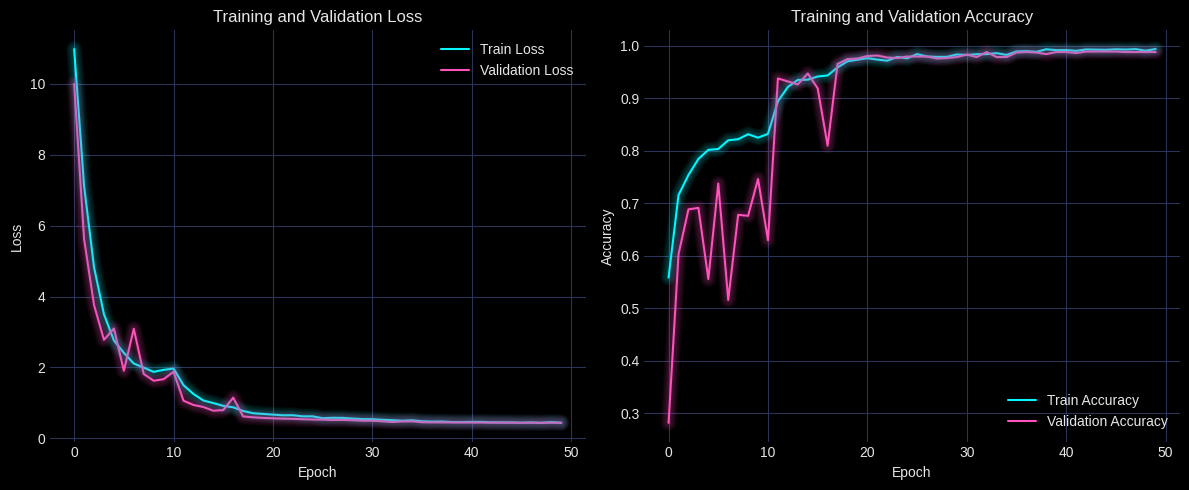

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5), facecolor="black")

plt.subplot(1, 2, 1, facecolor='black')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
mplcyberpunk.make_lines_glow()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2, facecolor='black')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
mplcyberpunk.make_lines_glow()

plt.tight_layout()
plt.show()


33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 358ms/step


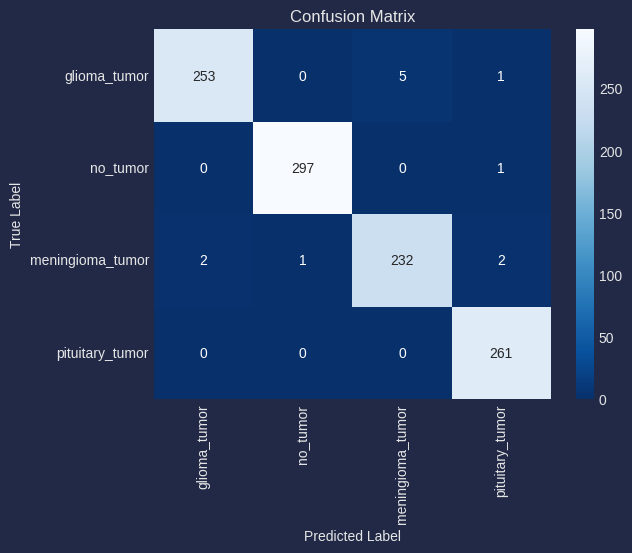

In [ ]:

# Evaluation
y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(model.predict(X_test), axis=1)

heatmap = sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



In [ ]:
print(classification_report(y_true_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       259
           1       1.00      1.00      1.00       298
           2       0.98      0.98      0.98       237
           3       0.98      1.00      0.99       261

    accuracy                           0.99      1055
   macro avg       0.99      0.99      0.99      1055
weighted avg       0.99      0.99      0.99      1055



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted label: no_tumor 
Actual label: no_tumor 
Confidence: 100.00%



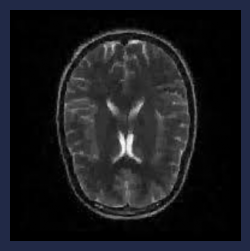

In [ ]:
random_index = np.random.randint(0, len(X_test))
random_img = X_test[random_index]
predictions = model.predict(random_img.reshape(1, 300, 300, 3))  # Reshape and preprocess the image

# Interpret the model's predictions
predicted_class = np.argmax(predictions)  # Get the index of the class with the highest probability
predicted_label = labels[predicted_class]  # Convert class to label
confidence = predictions[0][predicted_class]

actual_index = y_test[random_index]  # Get the one-hot encoded actual class
actual_class = np.argmax(actual_index)
actual_label = labels[actual_class]

# Display the image and prediction information
print(f"\033[94mPredicted label: {predicted_label}\033[0m \n\033[92mActual label: {actual_label}\033[0m \n\033[95mConfidence: {confidence*100:.2f}%\033[0m\n")
plt.figure(figsize = (3,3))
plt.imshow(random_img)
plt.axis('off')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 356ms/step - accuracy: 0.9884 - loss: 0.4415
Test Accuracy: 98.86%
